# Blood Cell AI - 環境構築とデータ準備

ResNet18とViTによる血液細胞2クラス分類（TensorFlow/Keras版）

## 1. TensorFlow + GPU確認

In [1]:
import tensorflow as tf
import numpy as np

print(f"TensorFlow Version: {tf.__version__}")
print(f"NumPy Version: {np.__version__}")

# GPU確認
gpus = tf.config.list_physical_devices('GPU')
print(f"GPU Available: {len(gpus) > 0}")
if gpus:
    print(f"Device: {gpus[0].name}")
    # GPU演算テスト
    with tf.device('/GPU:0'):
        a = tf.random.normal([1000, 1000])
        b = tf.random.normal([1000, 1000])
        c = tf.matmul(a, b)
    print(f"GPU matmul test: OK ({c.shape})")
else:
    print("Device: CPU（GPUが検出されません）")

W0000 00:00:1782132945.643243      40 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782132945.643345      40 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782132945.643353      40 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782132945.643358      40 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
2026-06-22 12:55:45.653229: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow wi

TensorFlow Version: 2.19.1
NumPy Version: 2.1.3
GPU Available: True
Device: /physical_device:GPU:0


I0000 00:00:1782132971.664007      40 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 18019 MB memory:  -> device: 0, name: AMD Radeon RX 7900 XT, pci bus id: 0000:2d:00.0


GPU matmul test: OK ((1000, 1000))


## 2. 必要なパッケージ

In [2]:
# 既にインストール済みの場合はコメントアウト
# !pip install medmnist japanize-matplotlib scikit-learn seaborn pyyaml -q

## 3. BloodMNISTデータセットダウンロード

BloodMNISTはRGB画像・28×28ピクセル・全11959サンプル（学習用）

In [3]:
from medmnist import BloodMNIST
import numpy as np

# NumPy配列として読み込み（TFだとImageFolderよりnpzが扱いやすい）
print("Downloading BloodMNIST dataset...")
train_dataset = BloodMNIST(split="train", download=True, root="../data")
val_dataset = BloodMNIST(split="val", download=True, root="../data")
test_dataset = BloodMNIST(split="test", download=True, root="../data")

# 画像とラベルをNumPy配列で取得（medmnist >= 3.0）
# x: (N, 28, 28, 3) uint8, y: (N, 1) int
x_train = train_dataset.imgs          # (N, 28, 28, 3) NHWC形式
y_train = train_dataset.labels.squeeze()  # (N,) 0-7のクラスラベル
x_val = val_dataset.imgs
y_val = val_dataset.labels.squeeze()
x_test = test_dataset.imgs
y_test = test_dataset.labels.squeeze()

print(f"Train: {len(x_train)}")
print(f"Val:   {len(x_val)}")
print(f"Test:  {len(x_test)}")
print(f"Image shape: {x_train.shape}")  # (N, 28, 28, 3) - NHWC形式

Train: 11959
Val:   1712
Test:  3421
Image shape: (11959, 28, 28, 3)


## 4. BloodMNIST 8クラス定義

専門家が形態学的基準で分類した8クラス

In [4]:
# 8クラス定義（PyTorch版と同一）
class_names = {
    0: ("basophil", "好塩基球", "成熟"),
    1: ("eosinophil", "好酸球", "成熟"),
    2: ("erythroblast", "赤芽球", "未熟"),
    3: ("immature granulocytes", "未熟顆粒球", "未熟"),
    4: ("lymphocyte", "リンパ球", "成熟"),
    5: ("monocyte", "単球", "成熟"),
    6: ("neutrophil", "好中球", "成熟"),
    7: ("platelet", "血小板", "成熟")
}

print("BloodMNIST 8クラス定義:")
print("-" * 50)
for label, (en, ja, group) in class_names.items():
    mark = "★" if group == "未熟" else ""
    print(f"{label}: {en:25} ({ja:6}) [{group}]{mark}")

print("\n「未熟」細胞の臨床的意義:")
print("- 通常、末梢血にはほとんど存在しない")
print("- 出現は骨髄異常（白血病、MDS等）を示唆")

BloodMNIST 8クラス定義:
--------------------------------------------------
0: basophil                  (好塩基球  ) [成熟]
1: eosinophil                (好酸球   ) [成熟]
2: erythroblast              (赤芽球   ) [未熟]★
3: immature granulocytes     (未熟顆粒球 ) [未熟]★
4: lymphocyte                (リンパ球  ) [成熟]
5: monocyte                  (単球    ) [成熟]
6: neutrophil                (好中球   ) [成熟]
7: platelet                  (血小板   ) [成熟]

「未熟」細胞の臨床的意義:
- 通常、末梢血にはほとんど存在しない
- 出現は骨髄異常（白血病、MDS等）を示唆


## 5. 2クラス分類（グループ化）

8クラス → 成熟(0) / 未熟(1) の2クラスに変換

In [5]:
# 2クラスにグループ化（PyTorch版と同一のロジック）
MATURE_LABELS = {0, 1, 4, 5, 6, 7}
IMMATURE_LABELS = {2, 3}

def get_binary_label(label):
    """8クラスラベルを2クラスに変換（0: 成熟, 1: 未熟）"""
    return 1 if label in IMMATURE_LABELS else 0

# ベクトル化で2クラスラベルを作成
y_train_binary = np.array([get_binary_label(l) for l in y_train])
y_val_binary = np.array([get_binary_label(l) for l in y_val])
y_test_binary = np.array([get_binary_label(l) for l in y_test])

print("2クラス分類:")
print(f"  成熟細胞 (Class 0): {sorted(MATURE_LABELS)}")
print(f"    → {', '.join([class_names[l][1] for l in sorted(MATURE_LABELS)])}")
print(f"  未熟細胞 (Class 1): {sorted(IMMATURE_LABELS)}")
print(f"    → {', '.join([class_names[l][1] for l in sorted(IMMATURE_LABELS)])}")

2クラス分類:
  成熟細胞 (Class 0): [0, 1, 4, 5, 6, 7]
    → 好塩基球, 好酸球, リンパ球, 単球, 好中球, 血小板
  未熟細胞 (Class 1): [2, 3]
    → 赤芽球, 未熟顆粒球


## 6. tf.data.Dataset作成

NumPy配列からtf.data.Datasetを構築。学習用にデータ拡張とprefetchを設定

In [6]:
import tensorflow as tf

AUTOTUNE = tf.data.AUTOTUNE
BATCH_SIZE = 64

# 正規化: uint8 [0,255] → float32 [0,1]
x_train_f = x_train.astype('float32') / 255.0
x_val_f = x_val.astype('float32') / 255.0
x_test_f = x_test.astype('float32') / 255.0

# 簡易データ拡張（学習データのみ）
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
])

# tf.data.Dataset作成
train_ds = tf.data.Dataset.from_tensor_slices((x_train_f, y_train_binary))
train_ds = train_ds.shuffle(buffer_size=len(x_train_f)).batch(BATCH_SIZE)
train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((x_val_f, y_val_binary)).batch(BATCH_SIZE).prefetch(AUTOTUNE)
test_ds = tf.data.Dataset.from_tensor_slices((x_test_f, y_test_binary)).batch(BATCH_SIZE).prefetch(AUTOTUNE)

# 確認
for images, labels in train_ds.take(1):
    print(f"Batch shape: {images.shape}")  # (64, 28, 28, 3)
    print(f"Label shape: {labels.shape}")   # (64,)
    print(f"Image dtype: {images.dtype}")   # float32
    print(f"Image range: [{images.numpy().min():.2f}, {images.numpy().max():.2f}]")
    print(f"Labels: {labels.numpy()[:8]}")   # 0 or 1

Batch shape: (64, 28, 28, 3)
Label shape: (64,)
Image dtype: <dtype: 'float32'>
Image range: [0.07, 1.00]
Labels: [0 0 1 0 0 1 0 0]


2026-06-22 12:56:23.313278: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## 7. データサンプル表示

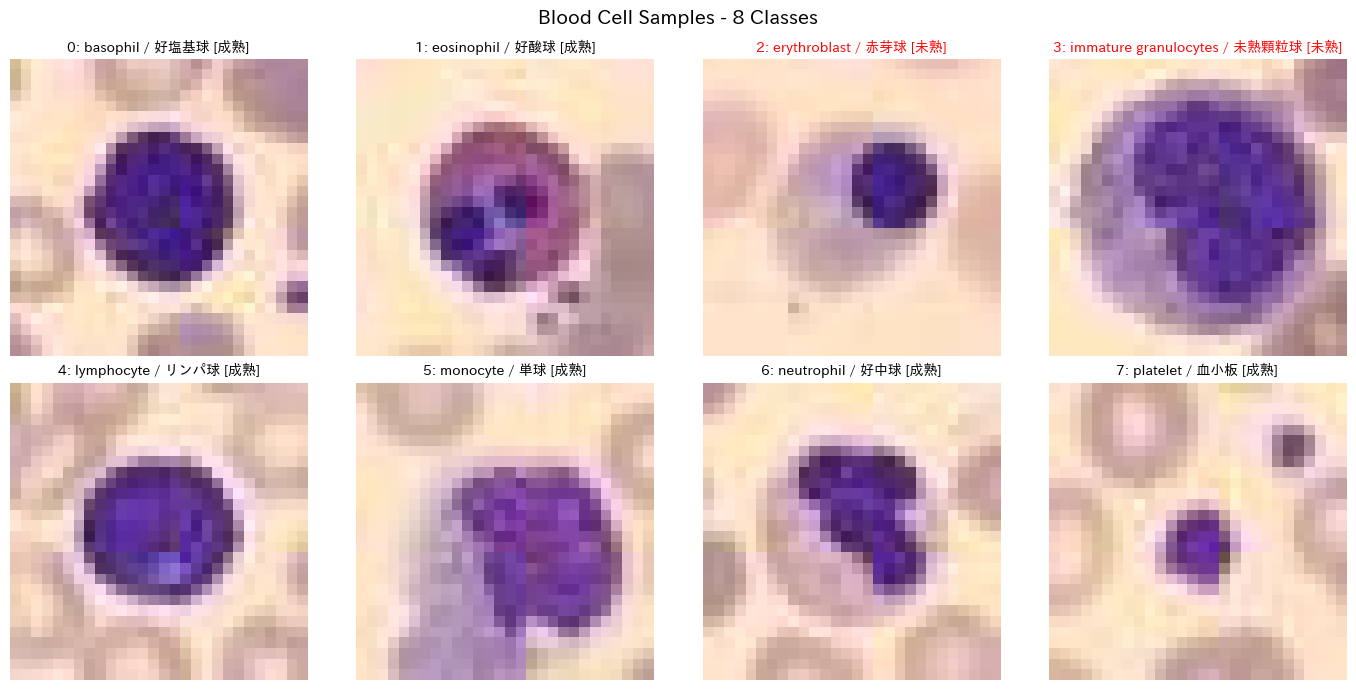

保存完了: ../images/blood_cell_samples_8classes.png


In [7]:
import matplotlib.pyplot as plt
import japanize_matplotlib
import numpy as np
import os

os.makedirs("../images", exist_ok=True)

# 各クラスから1枚ずつ表示
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle("Blood Cell Samples - 8 Classes", fontsize=14)

# 各クラスの最初の画像を取得
class_images = {}
for i in range(len(x_train)):
    label = int(y_train[i])
    if label not in class_images:
        class_images[label] = x_train[i]  # uint8のまま表示
    if len(class_images) == 8:
        break

# 表示
for idx in range(8):
    ax = axes[idx // 4, idx % 4]
    img = class_images[idx]  # (28, 28, 3) uint8
    en, ja, group = class_names[idx]
    color = "red" if group == "未熟" else "black"
    ax.imshow(img)
    ax.set_title(f"{idx}: {en} / {ja} [{group}]", fontsize=10, color=color)
    ax.axis("off")

plt.tight_layout()
plt.savefig("../images/blood_cell_samples_8classes.png", dpi=150, bbox_inches="tight")
plt.show()
print("保存完了: ../images/blood_cell_samples_8classes.png")

## 8. 2クラス分布確認

Train Set Distribution:
  成熟細胞: 8848 (74.0%)
  未熟細胞: 3111 (26.0%)


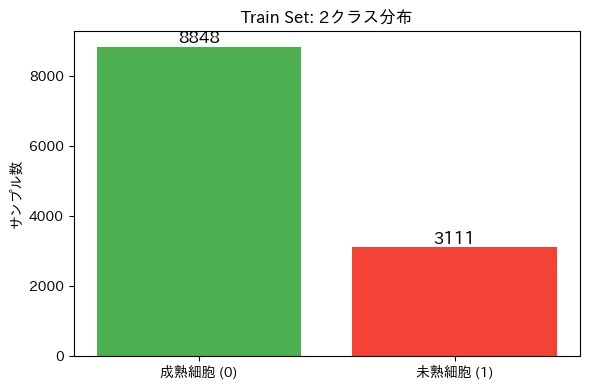

In [8]:
# クラス分布（2クラス）
mature_count = np.sum(y_train_binary == 0)
immature_count = np.sum(y_train_binary == 1)

print(f"Train Set Distribution:")
print(f"  成熟細胞: {mature_count} ({mature_count/len(y_train_binary)*100:.1f}%)")
print(f"  未熟細胞: {immature_count} ({immature_count/len(y_train_binary)*100:.1f}%)")

# クラス比率の可視化
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["成熟細胞 (0)", "未熟細胞 (1)"], [mature_count, immature_count],
       color=["#4CAF50", "#F44336"])
ax.set_title("Train Set: 2クラス分布")
ax.set_ylabel("サンプル数")
for i, v in enumerate([mature_count, immature_count]):
    ax.text(i, v + 100, str(v), ha='center', fontsize=12)
plt.tight_layout()
plt.savefig("../images/class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## ✅ 準備完了

次のステップ：
1. `02_ResNet18学習.ipynb` - ResNet18V2で学習
2. `03_ViT学習.ipynb` - ViTで学習
3. `04_最終評価.ipynb` - 両モデルの精度比較